# Stage 9 – Out-of-time testing and drift monitoring

A random train/test split mixes loans from every year, so the model is tested on the same era it learned from. A lender uses a model on **future** applicants. This notebook:

1. trains on loans issued **2007–2015** and tests separately on **2016, 2017 and 2018**,
2. compares that with a random split on the same data and pipeline,
3. measures drift with the **Population Stability Index (PSI)** for the model score and key features.

It reuses the leak-free preprocessing from notebook 03 and the monotonic constraints from notebook 08. The issue date was dropped in notebook 01, so it is read back from the raw file and matched by loan `id`.

## 1. Load data and attach the issue date

In [1]:
import os, gc, warnings
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import xgboost as xgb
import joblib
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc

warnings.filterwarnings("ignore")

def first_existing(paths):
    return next((p for p in paths if os.path.exists(p)), paths[0])

CLEAN_FILE = first_existing([
    "../data/accepted_cleaned.csv",
    r"D:\credit-risk-xai\credit-risk-xai\data\accepted_cleaned.csv",
])
RAW_FILE = first_existing([
    "../data/accepted_2007_to_2018Q4.csv",
    r"D:\credit-risk-xai\credit-risk-xai\data\accepted_2007_to_2018Q4.csv",
])
SAVE_DIR = "../outputs/notebook9_outputs"
os.makedirs(SAVE_DIR, exist_ok=True)

RANDOM_STATE = 42
SAMPLE_SIZE = 300_000
TARGET_COL = "default"
TRAIN_END_YEAR = 2015          # train on loans issued up to and including this year
print("Cleaned data:", CLEAN_FILE)
print("Raw data (for issue_d):", RAW_FILE)

def norm_id(series):
    return series.astype(str).str.strip().str.replace(r"\.0$", "", regex=True)

# Read everything as text with polars (fast, no type-guessing errors), sample, then hand over to pandas
clean = pl.read_csv(CLEAN_FILE, infer_schema_length=0)
print("Cleaned rows:", clean.height)
df = clean.sample(n=min(SAMPLE_SIZE, clean.height), seed=RANDOM_STATE).to_pandas()
del clean
gc.collect()

raw_dates = pl.read_csv(RAW_FILE, columns=["id", "issue_d"], infer_schema_length=0).to_pandas()
raw_dates["id"] = norm_id(raw_dates["id"])
raw_dates = raw_dates.dropna(subset=["issue_d"]).drop_duplicates("id")

df["id"] = norm_id(df["id"])
df = df.merge(raw_dates, on="id", how="left")
del raw_dates
gc.collect()
match_rate = df["issue_d"].notna().mean()
print(f"Issue date found for {match_rate:.1%} of sampled loans")
if match_rate < 0.95:
    raise ValueError("Too few loans matched on id - check the id column in both files.")

df["issue_date"] = pd.to_datetime(df["issue_d"], format="%b-%Y", errors="coerce")
df["issue_year"] = df["issue_date"].dt.year
df = df.dropna(subset=["issue_year"]).reset_index(drop=True)
df["issue_year"] = df["issue_year"].astype(int)

t = df[TARGET_COL].astype(str).str.lower().map({"1": 1, "0": 0, "true": 1, "false": 0, "1.0": 1, "0.0": 0})
df[TARGET_COL] = t.fillna(0).astype(int)
print("Sample shape:", df.shape)

Cleaned data: D:\credit-risk-xai\credit-risk-xai\data\accepted_cleaned.csv
Raw data (for issue_d): D:\credit-risk-xai\credit-risk-xai\data\accepted_2007_to_2018Q4.csv
Cleaned rows: 1345310
Issue date found for 100.0% of sampled loans
Sample shape: (300000, 96)


## 2. Default rate by issue year

Only loans with a final outcome (Fully Paid or Charged Off) were kept in notebook 01. Loans issued in 2016–2018 had not reached the end of their term by the end of 2018, so the ones that *are* finished are mostly early payoffs or early charge-offs. That makes later years look different for reasons that are about data collection, not borrowers, and it is worth keeping in mind when reading the out-of-time results.

 issue_year  loans default_rate
       2007     63        11.1%
       2008    340        17.1%
       2009   1050        13.3%
       2010   2613        13.4%
       2011   4869        15.2%
       2012  11821        16.1%
       2013  30022        15.7%
       2014  49920        18.3%
       2015  83636        20.4%
       2016  65424        23.1%
       2017  37592        23.1%
       2018  12650        16.3%


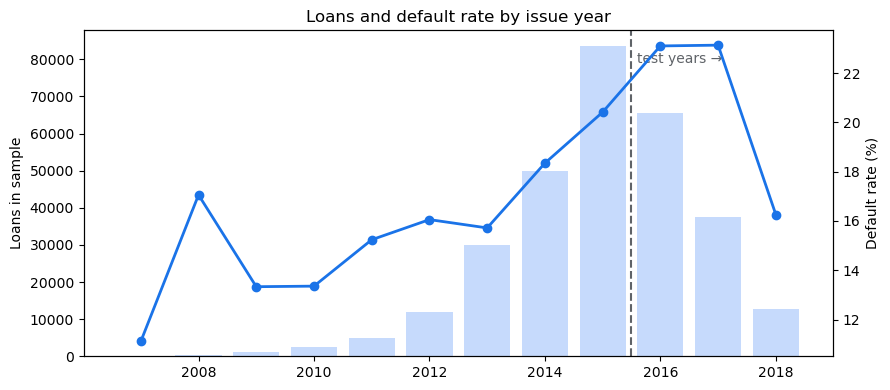

In [2]:
by_year = (df.groupby("issue_year")[TARGET_COL]
             .agg(loans="count", default_rate="mean")
             .reset_index())
print(by_year.to_string(index=False, formatters={"default_rate": "{:.1%}".format}))
by_year.to_csv(os.path.join(SAVE_DIR, "default_rate_by_year.csv"), index=False)

fig, ax1 = plt.subplots(figsize=(9, 4))
ax1.bar(by_year["issue_year"], by_year["loans"], color="#c6dafc", label="Loans in sample")
ax1.set_ylabel("Loans in sample")
ax2 = ax1.twinx()
ax2.plot(by_year["issue_year"], by_year["default_rate"] * 100, color="#1a73e8", marker="o", linewidth=2)
ax2.set_ylabel("Default rate (%)")
ax1.axvline(TRAIN_END_YEAR + 0.5, color="#5f6368", linestyle="--")
ax1.text(TRAIN_END_YEAR + 0.6, ax1.get_ylim()[1] * 0.9, "test years →", color="#5f6368")
plt.title("Loans and default rate by issue year")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "default_rate_by_year.png"), dpi=200)
plt.show()

## 3. Leak-free preprocessing, fitted on the training period only

In [3]:
LEAK_COLS = [
    "loan_status", "total_pymnt", "total_pymnt_inv", "total_rec_prncp", "total_rec_int",
    "total_rec_late_fee", "last_pymnt_amnt", "recoveries", "collection_recovery_fee",
    "last_pymnt_d", "next_pymnt_d", "last_credit_pull_d", "out_prncp", "out_prncp_inv",
    "settlement_status", "settlement_date", "settlement_amount", "settlement_percentage",
    "debt_settlement_flag", "last_fico_range_low", "last_fico_range_high",
    "id", "desc", "url", "title", "zip_code", "addr_state", "policy_code",
    "issue_d", "issue_date", "issue_year",
]
TE_SMOOTHING = 20
MAX_LARGE_USE = 8

class Preprocessor:
    """Learns everything from the training rows only, then applies it to any other rows."""

    def fit_transform(self, train):
        feats = [c for c in train.columns if c not in LEAK_COLS and c != TARGET_COL]
        # drop constant columns
        feats = [c for c in feats if train[c].nunique(dropna=True) > 1]
        self.numeric, cats = [], []
        for c in feats:
            s = train[c].dropna().head(500)
            frac = pd.to_numeric(s, errors="coerce").notna().mean() if len(s) else 0
            (self.numeric if frac > 0.8 else cats).append(c)
        cat_df = train[cats].astype(str)
        self.small = [c for c in cats if cat_df[c].nunique() < 20]
        large = [c for c in cats if c not in self.small]
        large = sorted(large, key=lambda c: cat_df[c].value_counts().iloc[:100].sum(), reverse=True)
        self.te_cols, extra_small = large[:MAX_LARGE_USE], large[MAX_LARGE_USE:]
        self.trunc = extra_small
        self.small = self.small + extra_small

        y = train[TARGET_COL].astype(int)
        self.gmean = y.mean()
        # target encoding: out-of-fold on train rows
        te_train = pd.DataFrame(index=train.index)
        self.te_maps = {}
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
        for c in self.te_cols:
            col = train[c].astype(str)
            oof = pd.Series(self.gmean, index=train.index, dtype=float)
            for fit_i, enc_i in skf.split(train, y):
                m = self._means(col.iloc[fit_i], y.iloc[fit_i])
                oof.iloc[enc_i] = col.iloc[enc_i].map(m).fillna(self.gmean).values
            te_train[c + "_te"] = oof.values
            self.te_maps[c] = self._means(col, y)

        self.ord = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
        small_train = self._small_frame(train)
        ord_train = self.ord.fit_transform(small_train) if self.small else np.empty((len(train), 0))

        self.num_pipe = Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler())])
        num_train = self.num_pipe.fit_transform(self._num_frame(train)) if self.numeric else np.empty((len(train), 0))

        self.feature_names = self.numeric + [c + "_ord" for c in self.small] + [c + "_te" for c in self.te_cols]
        return np.hstack([num_train, ord_train, te_train.to_numpy(dtype=float)])

    def transform(self, other):
        te = np.column_stack([other[c].astype(str).map(self.te_maps[c]).fillna(self.gmean).to_numpy(dtype=float)
                              for c in self.te_cols]) if self.te_cols else np.empty((len(other), 0))
        ord_ = self.ord.transform(self._small_frame(other)) if self.small else np.empty((len(other), 0))
        num = self.num_pipe.transform(self._num_frame(other)) if self.numeric else np.empty((len(other), 0))
        return np.hstack([num, ord_, te])

    def _means(self, col, y):
        stats = pd.DataFrame({"c": col.values, "y": y.values}).groupby("c")["y"].agg(["mean", "count"])
        return (stats["mean"] * stats["count"] + self.gmean * TE_SMOOTHING) / (stats["count"] + TE_SMOOTHING)

    def _small_frame(self, d):
        out = d[self.small].astype(str).copy()
        for c in self.trunc:
            out[c] = out[c].str[:30]
        return out

    def _num_frame(self, d):
        return d[self.numeric].apply(pd.to_numeric, errors="coerce")

train_df = df[df["issue_year"] <= TRAIN_END_YEAR].reset_index(drop=True)
test_years = sorted(int(y) for y in df["issue_year"].unique() if y > TRAIN_END_YEAR)
print(f"Train: {len(train_df):,} loans issued {train_df['issue_year'].min()}-{TRAIN_END_YEAR}")
for yr in test_years:
    print(f"Test {yr}: {(df['issue_year'] == yr).sum():,} loans")

prep = Preprocessor()
X_train = prep.fit_transform(train_df)
y_train = train_df[TARGET_COL].to_numpy()
FEATURES = prep.feature_names
print("Features:", len(FEATURES))

Train: 184,334 loans issued 2007-2015
Test 2016: 65,424 loans
Test 2017: 37,592 loans
Test 2018: 12,650 loans
Features: 84


## 4. Train monotonic XGBoost (same direction rules as notebook 08)

In [4]:
DIRECTION_RULES = {
    "int_rate": +1, "dti": +1, "revol_util": +1, "bc_util": +1, "all_util": +1, "percent_bc_gt_75": +1,
    "delinq_2yrs": +1, "pub_rec": +1, "pub_rec_bankruptcies": +1, "num_accts_ever_120_pd": +1,
    "num_tl_90g_dpd_24m": +1, "inq_last_6mths": +1, "inq_last_12m": +1,
    "sub_grade_te": +1, "emp_title_te": +1, "earliest_cr_line_te": +1, "grade_ord": +1, "term_ord": +1,
    "annual_inc": -1, "fico_range_low": -1, "fico_range_high": -1, "pct_tl_nvr_dlq": -1,
}
constraint_str = "(" + ",".join(str(DIRECTION_RULES.get(f, 0)) for f in FEATURES) + ")"

PARAMS = dict(objective="binary:logistic", eval_metric="auc", tree_method="hist",
              learning_rate=0.05, max_depth=5, subsample=0.8, colsample_bytree=0.8,
              random_state=RANDOM_STATE, n_jobs=-1, monotone_constraints=constraint_str)

# Early stopping on the LAST training year, so tuning also looks forward in time
last = train_df["issue_year"].to_numpy() == TRAIN_END_YEAR
es_model = xgb.XGBClassifier(**PARAMS, n_estimators=800, early_stopping_rounds=50)
es_model.fit(X_train[~last], y_train[~last], eval_set=[(X_train[last], y_train[last])], verbose=False)
best_n = int(getattr(es_model, "best_iteration", 299)) + 1
print("Trees chosen by early stopping on", TRAIN_END_YEAR, ":", best_n)

# Refit on the whole training period with that number of trees
model = xgb.XGBClassifier(**PARAMS, n_estimators=best_n)
model.fit(X_train, y_train)

Trees chosen by early stopping on 2015 : 269


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_thresho...
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan,
              monotone_constraints='(0,0,0,1,0,-1,1,1,-1,-1,1,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,-1,1,1,0,0,0,0,0,1,1,0,0,0,0,0,1,1,1)',
              multi_strategy=None, n_estimators=269, n_jobs=-1,
              num_parallel_tree=None, random_state=42, ...)

## 5. Out-of-time results vs a random split

        evaluation  loans default_rate ROC_AUC PR_AUC
Random 80/20 split  60000        20.0%  0.7283 0.4012
  Out-of-time 2016  65424        23.1%  0.7171 0.4271
  Out-of-time 2017  37592        23.1%  0.7054 0.4055
  Out-of-time 2018  12650        16.3%  0.6979 0.2888


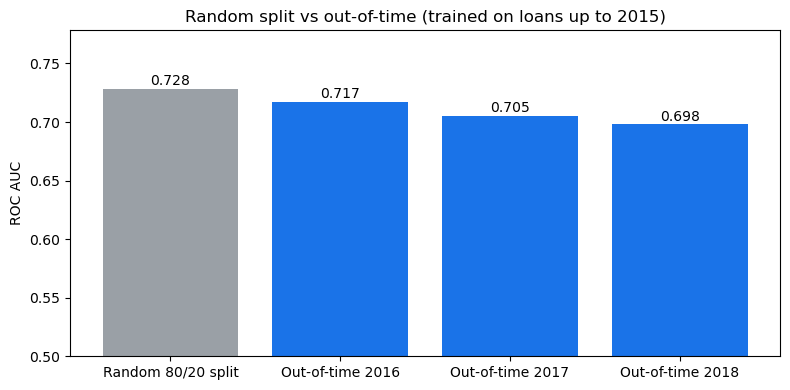

In [5]:
def metrics(y, p):
    prec, rec, _ = precision_recall_curve(y, p)
    return roc_auc_score(y, p), auc(rec, prec)

rows = []
p_train = model.predict_proba(X_train)[:, 1]
test_scores = {}
for yr in test_years:
    part = df[df["issue_year"] == yr]
    X_yr = prep.transform(part)
    p = model.predict_proba(X_yr)[:, 1]
    test_scores[yr] = (p, X_yr)
    roc, pr = metrics(part[TARGET_COL].to_numpy(), p)
    rows.append({"evaluation": f"Out-of-time {yr}", "loans": len(part),
                 "default_rate": part[TARGET_COL].mean(), "ROC_AUC": roc, "PR_AUC": pr})

# Random split on the SAME sample, pipeline and settings, for comparison
rs_train, rs_test = train_test_split(df, test_size=0.2, random_state=RANDOM_STATE, stratify=df[TARGET_COL])
rs_prep = Preprocessor()
Xr_train = rs_prep.fit_transform(rs_train.reset_index(drop=True))
rs_params = dict(PARAMS, monotone_constraints="(" + ",".join(str(DIRECTION_RULES.get(f, 0)) for f in rs_prep.feature_names) + ")")
rs_model = xgb.XGBClassifier(**rs_params, n_estimators=best_n)
rs_model.fit(Xr_train, rs_train[TARGET_COL].to_numpy())
roc, pr = metrics(rs_test[TARGET_COL].to_numpy(), rs_model.predict_proba(rs_prep.transform(rs_test))[:, 1])
rows.insert(0, {"evaluation": "Random 80/20 split", "loans": len(rs_test),
                "default_rate": rs_test[TARGET_COL].mean(), "ROC_AUC": roc, "PR_AUC": pr})

results = pd.DataFrame(rows)
print(results.to_string(index=False, formatters={"default_rate": "{:.1%}".format,
                                                  "ROC_AUC": "{:.4f}".format, "PR_AUC": "{:.4f}".format}))
results.to_csv(os.path.join(SAVE_DIR, "out_of_time_results.csv"), index=False)

plt.figure(figsize=(8, 4))
colors = ["#9aa0a6"] + ["#1a73e8"] * (len(results) - 1)
plt.bar(results["evaluation"], results["ROC_AUC"], color=colors)
for i, v in enumerate(results["ROC_AUC"]):
    plt.text(i, v + 0.003, f"{v:.3f}", ha="center")
plt.ylim(0.5, max(results["ROC_AUC"]) + 0.05)
plt.ylabel("ROC AUC")
plt.title(f"Random split vs out-of-time (trained on loans up to {TRAIN_END_YEAR})")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "out_of_time_auc.png"), dpi=200)
plt.show()

## 6. Drift: Population Stability Index (PSI)

PSI compares how a variable is distributed in a new period against the training period (10 bins from the training deciles). A common rule of thumb in credit risk:

- **below 0.10** – stable
- **0.10 to 0.25** – some shift, keep an eye on it
- **above 0.25** – significant shift, review or retrain the model

PSI vs training period (rows = variable, columns = test year):
issue_year             2016   2017   2018
model_score           0.014  0.019  0.032
grade_ord             0.008  0.019  0.042
sub_grade_te          0.077  0.089  0.122
term_ord              0.012  0.001  0.001
acc_open_past_24mths  0.052  0.050  0.060
home_ownership_ord    0.005  0.006  0.014
mort_acc              0.017  0.025  0.021
dti                   0.009  0.005  0.045
int_rate              0.082  0.097  0.147
emp_title_te          0.060  0.063  0.075
avg_cur_bal           0.059  0.069  0.097

Model score status by year: {2016: '0.014 (stable)', 2017: '0.019 (stable)', 2018: '0.032 (stable)'}


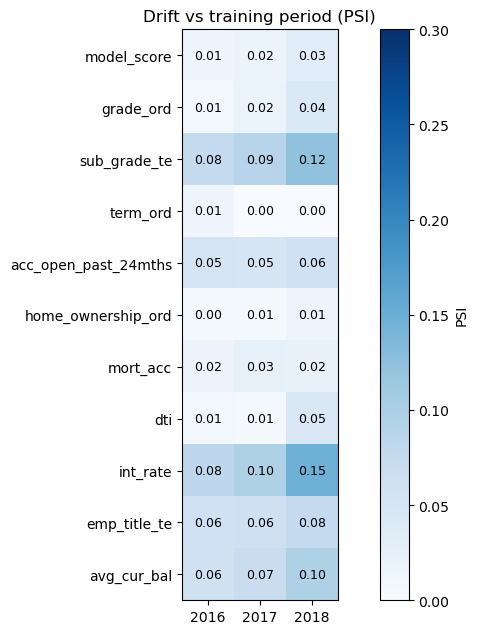

In [6]:
def psi(expected, actual, bins=10):
    expected = expected[~np.isnan(expected)]
    actual = actual[~np.isnan(actual)]
    levels = np.unique(expected)
    if len(levels) <= bins:
        # few distinct values (e.g. term, grade): compare the share of each value directly
        e = np.array([(expected == v).mean() for v in levels])
        a = np.array([(actual == v).mean() for v in levels])
    else:
        edges = np.unique(np.percentile(expected, np.linspace(0, 100, bins + 1)))
        edges[0], edges[-1] = -np.inf, np.inf
        e = np.histogram(expected, edges)[0] / len(expected)
        a = np.histogram(actual, edges)[0] / len(actual)
    e, a = np.clip(e, 1e-4, None), np.clip(a, 1e-4, None)
    return float(np.sum((a - e) * np.log(a / e)))

importance = pd.Series(model.feature_importances_, index=FEATURES).sort_values(ascending=False)
top_feats = importance.index[:10].tolist()

psi_rows = []
for yr in test_years:
    p, X_yr = test_scores[yr]
    row = {"issue_year": yr, "model_score": psi(p_train, p)}
    for f in top_feats:
        j = FEATURES.index(f)
        row[f] = psi(X_train[:, j], X_yr[:, j])
    psi_rows.append(row)
psi_table = pd.DataFrame(psi_rows).set_index("issue_year").T
print("PSI vs training period (rows = variable, columns = test year):")
print(psi_table.round(3).to_string())
psi_table.to_csv(os.path.join(SAVE_DIR, "psi_by_year.csv"))

def status(v):
    return "stable" if v < 0.10 else ("watch" if v < 0.25 else "significant")
print("\nModel score status by year:",
      {yr: f"{psi_table.loc['model_score', yr]:.3f} ({status(psi_table.loc['model_score', yr])})" for yr in test_years})

# heatmap
fig, ax = plt.subplots(figsize=(1.6 * len(test_years) + 4, 0.45 * len(psi_table) + 1.5))
vals = psi_table.to_numpy(dtype=float)
im = ax.imshow(vals, cmap="Blues", vmin=0, vmax=max(0.3, np.nanmax(vals)))
ax.set_xticks(range(len(test_years)), [str(y) for y in test_years])
ax.set_yticks(range(len(psi_table)), psi_table.index)
for i in range(vals.shape[0]):
    for j in range(vals.shape[1]):
        ax.text(j, i, f"{vals[i, j]:.2f}", ha="center", va="center",
                color="white" if vals[i, j] > 0.2 else "black", fontsize=9)
plt.colorbar(im, ax=ax, label="PSI")
ax.set_title("Drift vs training period (PSI)")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "psi_heatmap.png"), dpi=200, bbox_inches="tight")
plt.show()

## 7. Summary

In [7]:
rs = results.iloc[0]
oot = results.iloc[1:]
print("=== Summary ===")
print(f"Random split ROC AUC:  {rs['ROC_AUC']:.4f}")
for _, r in oot.iterrows():
    yr = int(r['evaluation'].split()[-1])
    print(f"{r['evaluation']}: ROC AUC {r['ROC_AUC']:.4f} | default rate {r['default_rate']:.1%} | "
          f"score PSI {psi_table.loc['model_score', yr]:.3f} ({status(psi_table.loc['model_score', yr])})")
joblib.dump({"model": model, "features": FEATURES}, os.path.join(SAVE_DIR, "xgb_out_of_time.joblib"))
print("Outputs saved in:", SAVE_DIR)

=== Summary ===
Random split ROC AUC:  0.7283
Out-of-time 2016: ROC AUC 0.7171 | default rate 23.1% | score PSI 0.014 (stable)
Out-of-time 2017: ROC AUC 0.7054 | default rate 23.1% | score PSI 0.019 (stable)
Out-of-time 2018: ROC AUC 0.6979 | default rate 16.3% | score PSI 0.032 (stable)
Outputs saved in: ../outputs/notebook9_outputs
